# Анализ данных о полетах (Полная версия)

В этом ноутбуке мы исследуем всю базу полетов, а затем фокусируемся на регионе Кобала в рамках летного сезона (15 мая - 15 сентября).

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from paraglideml.data.flight_parsing import load_flights_to_dataframe
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Загрузка данных

In [3]:
df = load_flights_to_dataframe(data_dir="../data/flights")
print(f"Всего полетов загружено: {len(df)}")

Found 40 files in ../data/flights matching *.json
Loading ../data/flights/xcontest_flights_at-25.json...
Loading ../data/flights/xcontest_flights_cr-23.json...
Loading ../data/flights/xcontest_flights_ru-25.json...
Loading ../data/flights/xcontest_flights_it-25.json...
Loading ../data/flights/xcontest_flights_sw-23.json...
Loading ../data/flights/xcontest_flights_fr-21.json...
Loading ../data/flights/xcontest_flights_sw-22.json...
Loading ../data/flights/xcontest_flights_cr-21.json...
Loading ../data/flights/xcontest_flights_de-24.json...
Loading ../data/flights/xcontest_flights_sw-24.json...
Loading ../data/flights/xcontest_flights_sl-21.json...
Loading ../data/flights/xcontest_flights_sw-25.json...
Loading ../data/flights/xcontest_flights_fr-23.json...
Loading ../data/flights/xcontest_flights_at-21.json...
Loading ../data/flights/xcontest_flights_ru-22.json...
Loading ../data/flights/xcontest_flights_fr-25.json...
Loading ../data/flights/xcontest_flights_sl-22.json...
Loading ../data

## 2. Глобальный пространственный анализ
Посмотрим, где находятся основные точки старта.

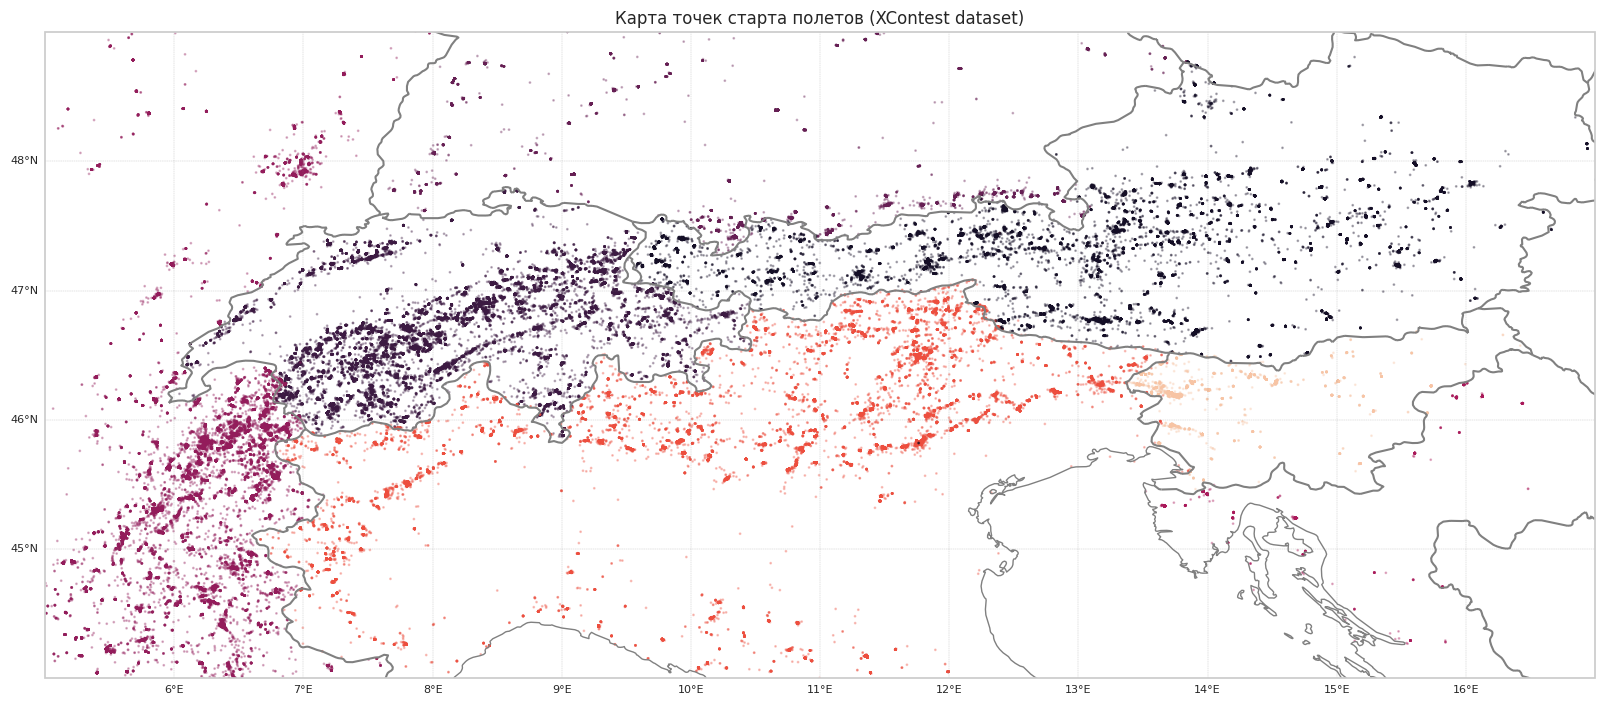

In [5]:
df_geo = df.dropna(subset=["takeoff_lat", "takeoff_lon"])

# Правильное решение с cartopy projection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Опционально: ограничить область (None = показывать всё)
BBOX = None  # Весь мир
BBOX = {"lon_min": 5, "lat_min": 44, "lon_max": 17, "lat_max": 49}  # Alps
#BBOX = {"lon_min": 13, "lon_max": 16, "lat_min": 45, "lat_max": 47}  # Slo
#BBOX = {"lon_min": 10, "lon_max": 16, "lat_min": 43, "lat_max": 47}  # Slo

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Ограничение по bbox (если задан)
if BBOX:
    ax.set_extent([BBOX["lon_min"], BBOX["lon_max"], BBOX["lat_min"], BBOX["lat_max"]], crs=ccrs.PlateCarree())

# Добавляем границы 
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='gray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='gray', zorder=2)

# Сетка по 1 градусу
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(range(-180, 181, 1))
gl.ylocator = mticker.FixedLocator(range(-90, 91, 1))
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Рисуем точки - важно указать transform для координат
ax.scatter(df_geo["takeoff_lon"], df_geo["takeoff_lat"], 
           c=df_geo["country"].astype('category').cat.codes, 
           alpha=0.3, s=1, transform=ccrs.PlateCarree(), zorder=1)
plt.title("Карта точек старта полетов (XContest dataset)")
plt.show()

## 3. Анализ дистанций полета
Распределение дальности полетов по всей базе.

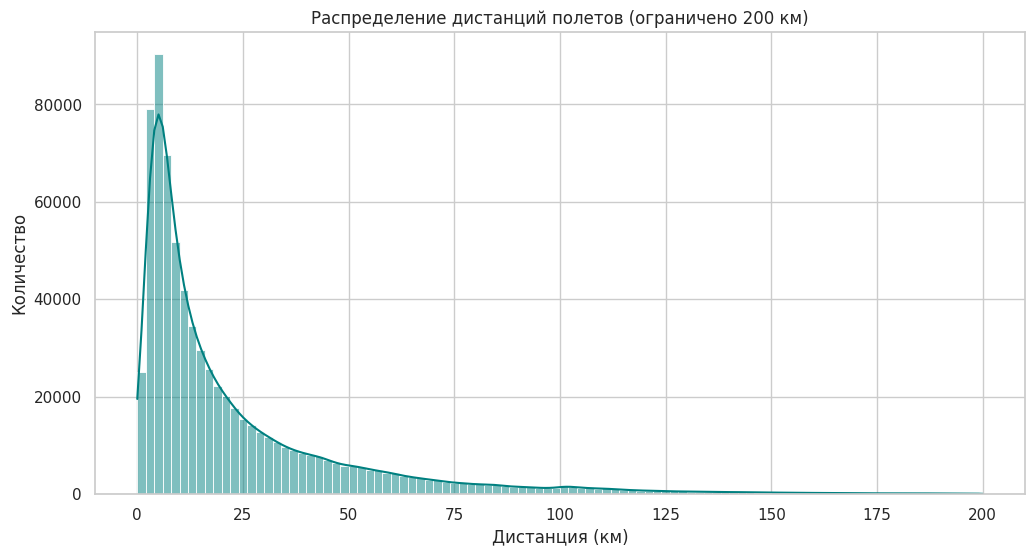

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df["distance"] < 200]["distance"], bins=100, kde=True, color="teal")
plt.title("Распределение дистанций полетов (ограничено 200 км)")
plt.xlabel("Дистанция (км)")
plt.ylabel("Количество")
plt.show()

## 4. Фокус на Kobala (Словения)
Фильтруем полеты для конкретной ячейки и анализируем летный сезон.

In [7]:
KOBALA_LAT, KOBALA_LON, TOLERANCE = 46.18, 13.78, 0.02
df_kobala = df_geo[(df_geo["takeoff_lat"].between(KOBALA_LAT-TOLERANCE, KOBALA_LAT+TOLERANCE)) & (df_geo["takeoff_lon"].between(KOBALA_LON-TOLERANCE, KOBALA_LON+TOLERANCE))].copy()
print(f"Полетов с Kobala: {len(df_kobala)}")

Полетов с Kobala: 13684


In [8]:
# Создаем целевую переменную (Target) внутри сезона 15.05 - 15.09
daily_stats = df_kobala.groupby(df_kobala["date"].dt.date).agg(flight_count=("id", "count")).reset_index()
daily_stats["date"] = pd.to_datetime(daily_stats["date"])
target_dates = []
for y in range(2021, 2026):
    rng = pd.date_range(f"{y}-05-15", f"{y}-09-15")
    target_dates.extend(rng)
df_target = pd.DataFrame({"date": target_dates})
df_target = df_target.merge(daily_stats, on="date", how="left").fillna(0)
df_target["is_flyable"] = (df_target["flight_count"] >= 3).astype(int)
print("Баланс классов в сезоне (Flyable vs Not):")
print(df_target["is_flyable"].value_counts(normalize=True))

Баланс классов в сезоне (Flyable vs Not):
is_flyable
1    0.685484
0    0.314516
Name: proportion, dtype: float64


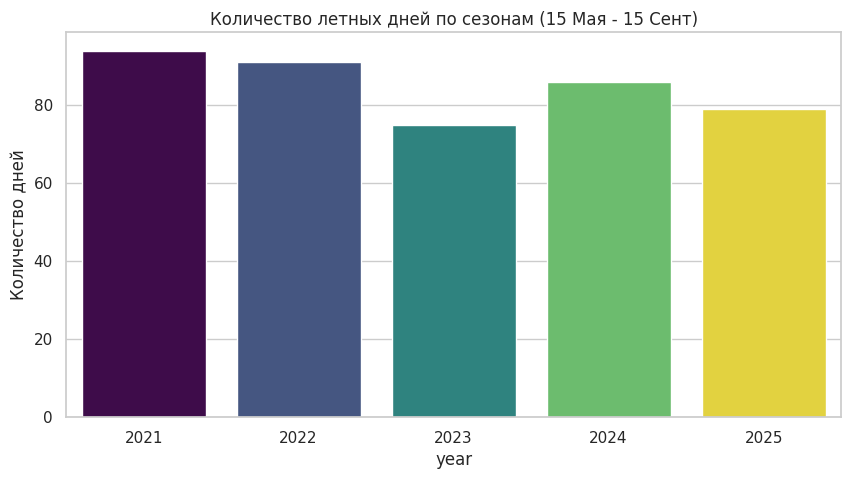

In [9]:
# Годовое распределение (исправлен Warning)
df_target["year"] = df_target["date"].dt.year
flyable_by_year = df_target.groupby("year")["is_flyable"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=flyable_by_year, x="year", y="is_flyable", hue="year", palette="viridis", legend=False)
plt.title("Количество летных дней по сезонам (15 Мая - 15 Сент)")
plt.ylabel("Количество дней")
plt.show()

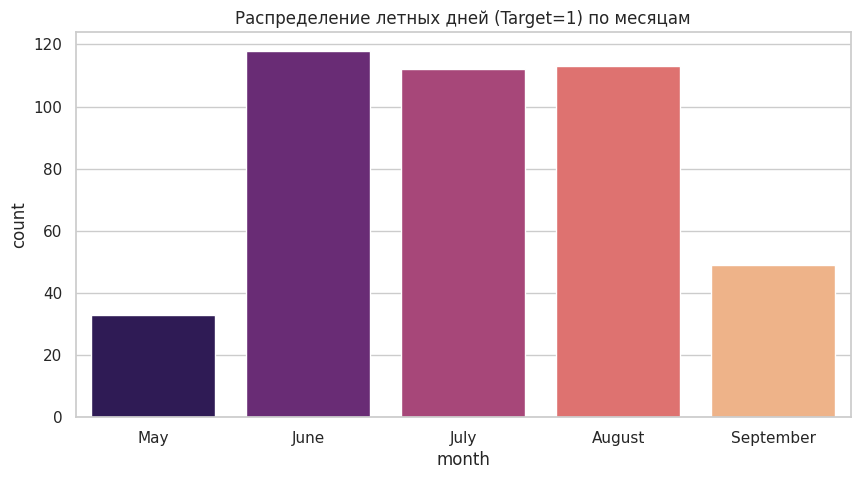

In [10]:
# Месячное распределение
df_target["month"] = df_target["date"].dt.month_name()
month_order = ["May", "June", "July", "August", "September"]
plt.figure(figsize=(10, 5))
sns.countplot(data=df_target[df_target["is_flyable"]==1], x="month", hue="month", order=month_order, palette="magma", legend=False)
plt.title("Распределение летных дней (Target=1) по месяцам")
plt.show()

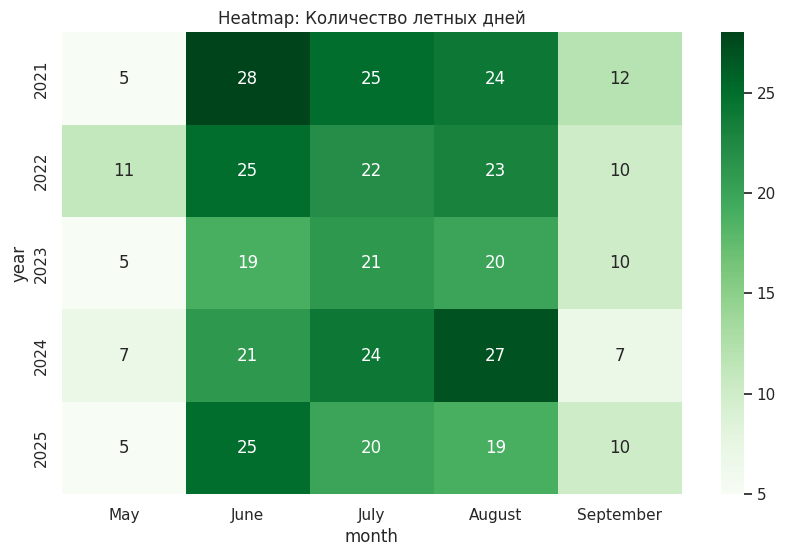

In [11]:
# Heatmap активности
pivot = df_target.pivot_table(index="year", columns="month", values="is_flyable", aggfunc="sum")
pivot = pivot[month_order]
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="g", cmap="Greens")
plt.title("Heatmap: Количество летных дней")
plt.show()